In [ ]:
import torch
import json
import requests
from PIL import Image
from transformers import AutoModel, AutoTokenizer, BridgeTowerConfig, BridgeTowerImageProcessor

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

MODEL_NAME = "BridgeTower/bridgetower-base"

config_url = f"https://huggingface.co/{MODEL_NAME}/raw/main/config.json"
config_dict = requests.get(config_url).json()
config_dict["model_type"] = "bridgetower"
config = BridgeTowerConfig.from_dict(config_dict)

model = AutoModel.from_pretrained(MODEL_NAME, config=config, trust_remote_code=True).to(device)
model.eval()

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({'pad_token': '[PAD]'})

image_processor = BridgeTowerImageProcessor.from_pretrained(MODEL_NAME, config=config, trust_remote_code=True)

url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
text = "a photo of two cats sleeping on a pink couch"

pixel_values = image_processor(image, return_tensors="pt")["pixel_values"].to(device)
text_inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128)
input_ids = text_inputs["input_ids"].to(device)
attention_mask = text_inputs["attention_mask"].to(device)

inputs = {"pixel_values": pixel_values, "input_ids": input_ids, "attention_mask": attention_mask}

tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
text_len = len(tokens)
patch_size = config.vision_config.patch_size
ph, pw = pixel_values.shape[-2] // patch_size, pixel_values.shape[-1] // patch_size
patch_len = ph * pw

print("\n" + "=" * 60)
print("SEQUENCE LENGTHS")
print("=" * 60)
print(f"Text tokens: {tokens}")
print(f"Text length: {text_len}")
print(f"Image patches: {ph} x {pw} = {patch_len}")
print(f"Total input_ids length: {input_ids.shape[1]}")

outputs = model(**inputs, output_attentions=True)

print("\n" + "=" * 60)
print("OUTPUT SHAPES")
print("=" * 60)
print(f"Output keys: {list(outputs.keys())}")
if hasattr(outputs, 'pooler_output'):
    print(f"Pooler output shape: {outputs.pooler_output.shape}")

print("\n" + "=" * 60)
print("ATTENTION MATRICES")
print("=" * 60)
if hasattr(outputs, 'attentions') and outputs.attentions is not None:
    n_layers = len(outputs.attentions)
    print(f"Number of layers: {n_layers}")
    first_attn = outputs.attentions[0]
    print(f"Type of first attention: {type(first_attn)}")
    if isinstance(first_attn, tuple):
        print(f"Tuple length: {len(first_attn)}")
        for i, elem in enumerate(first_attn):
            print(f"  Element {i} shape: {elem.shape}")
    else:
        print(f"Shape: {first_attn.shape}")

print("\n" + "=" * 60)
print("CROSS‑ATTENTION MODULES")
print("=" * 60)
module_names = list(model.named_modules())
for name, _ in module_names:
    if "crossattention" in name.lower():
        print(name)

print("\n" + "=" * 60)
print("GRADIENT FLOW TEST")
print("=" * 60)
if hasattr(outputs, 'pooler_output'):
    loss = outputs.pooler_output.mean()
    print("Using pooler_output.mean() as loss.")
else:
    loss = None

if loss is not None and hasattr(outputs, 'attentions') and outputs.attentions is not None:
    attn0 = outputs.attentions[0]
    if isinstance(attn0, tuple):
        attn0 = attn0[0]
    if attn0.grad_fn is not None:
        print("Attention tensors have grad_fn.")
        for layer_attn in outputs.attentions:
            if isinstance(layer_attn, tuple):
                for elem in layer_attn:
                    elem.retain_grad()
            else:
                layer_attn.retain_grad()
        loss.backward()
        last_layer = outputs.attentions[-1]
        if isinstance(last_layer, tuple):
            last_tensor = last_layer[-1]
        else:
            last_tensor = last_layer
        if last_tensor.grad is not None:
            print(f"Gradients received. Sum: {last_tensor.grad.abs().sum().item():.4f}")
        else:
            print("No gradients received.")
    else:
        print("Attention tensors are detached.")
else:
    print("Cannot test gradients.")

print("\n" + "=" * 60)
print("VERIFICATION COMPLETE")
print("=" * 60)

Using device: cuda


Loading weights:   0%|          | 0/695 [00:00<?, ?it/s]


SEQUENCE LENGTHS
Text tokens: ['<s>', 'a', 'Ġphoto', 'Ġof', 'Ġtwo', 'Ġcats', 'Ġsleeping', 'Ġon', 'Ġa', 'Ġpink', 'Ġcouch', '</s>']
Text length: 12
Image patches: 18 x 18 = 324
Total input_ids length: 12

OUTPUT SHAPES
Output keys: ['text_features', 'image_features', 'pooler_output', 'hidden_states', 'attentions']
Pooler output shape: torch.Size([1, 1536])

ATTENTION MATRICES
Number of layers: 6
Type of first attention: <class 'tuple'>
Tuple length: 2
  Element 0 shape: torch.Size([1, 12, 12, 12])
  Element 1 shape: torch.Size([1, 12, 325, 325])

CROSS‑ATTENTION MODULES
cross_modal_image_layers.0.crossattention
cross_modal_image_layers.0.crossattention.self
cross_modal_image_layers.0.crossattention.self.query
cross_modal_image_layers.0.crossattention.self.key
cross_modal_image_layers.0.crossattention.self.value
cross_modal_image_layers.0.crossattention.self.dropout
cross_modal_image_layers.0.crossattention.output
cross_modal_image_layers.0.crossattention.output.dense
cross_modal_image_l

Loading BridgeTower Foundation Model via Custom Config...


Loading weights:   0%|          | 0/695 [00:00<?, ?it/s]


Starting Visual Sanity Check...

[1/3] Image ID: 289343
Target Noun: 'dog'
  -> Captured 6 cross-attention layers.
  -> Attention Matrix Shape: torch.Size([6, 1, 12, 7, 325])
  -> Patch Center (Grid 18x18): (17, 11)
  -> Projected Image Coordinates: (514.3, 408.9)
Saved 'bridgetower_sanity_0.png'.

[2/3] Image ID: 61471
Target Noun: 'dog'
  -> Captured 6 cross-attention layers.
  -> Attention Matrix Shape: torch.Size([6, 1, 12, 7, 325])
  -> Patch Center (Grid 18x18): (11, 10)
  -> Projected Image Coordinates: (408.9, 280.0)
Saved 'bridgetower_sanity_1.png'.

[3/3] Image ID: 472375
Target Noun: 'dog'
  -> Captured 6 cross-attention layers.
  -> Attention Matrix Shape: torch.Size([6, 1, 12, 7, 325])
  -> Patch Center (Grid 18x18): (5, 11)
  -> Projected Image Coordinates: (187.0, 391.0)
Saved 'bridgetower_sanity_2.png'.

All 3 sanity checks saved. Please examine the images.


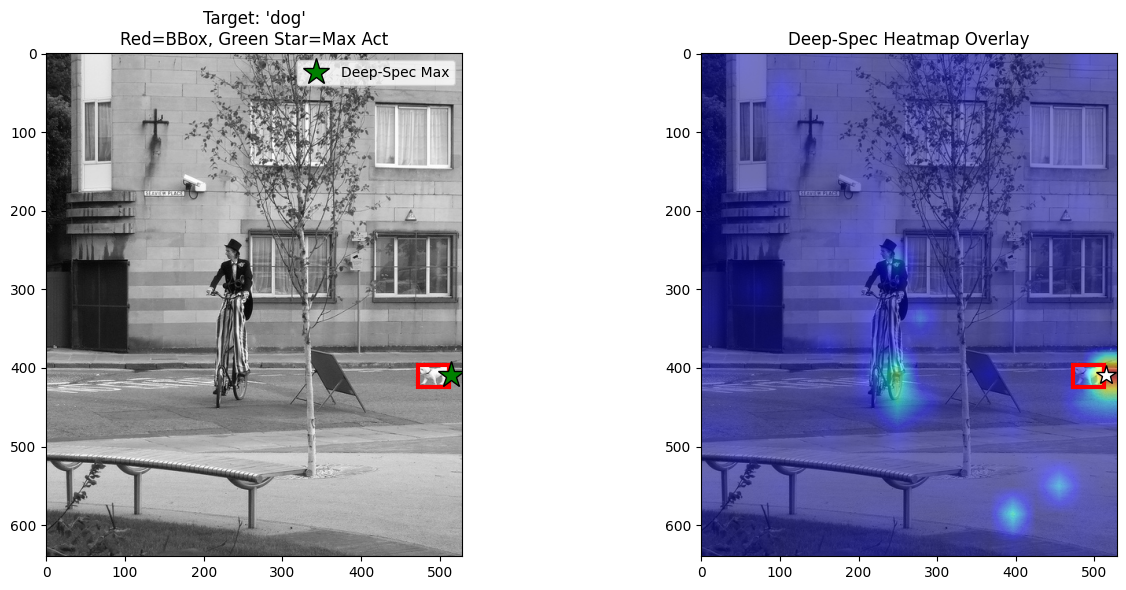

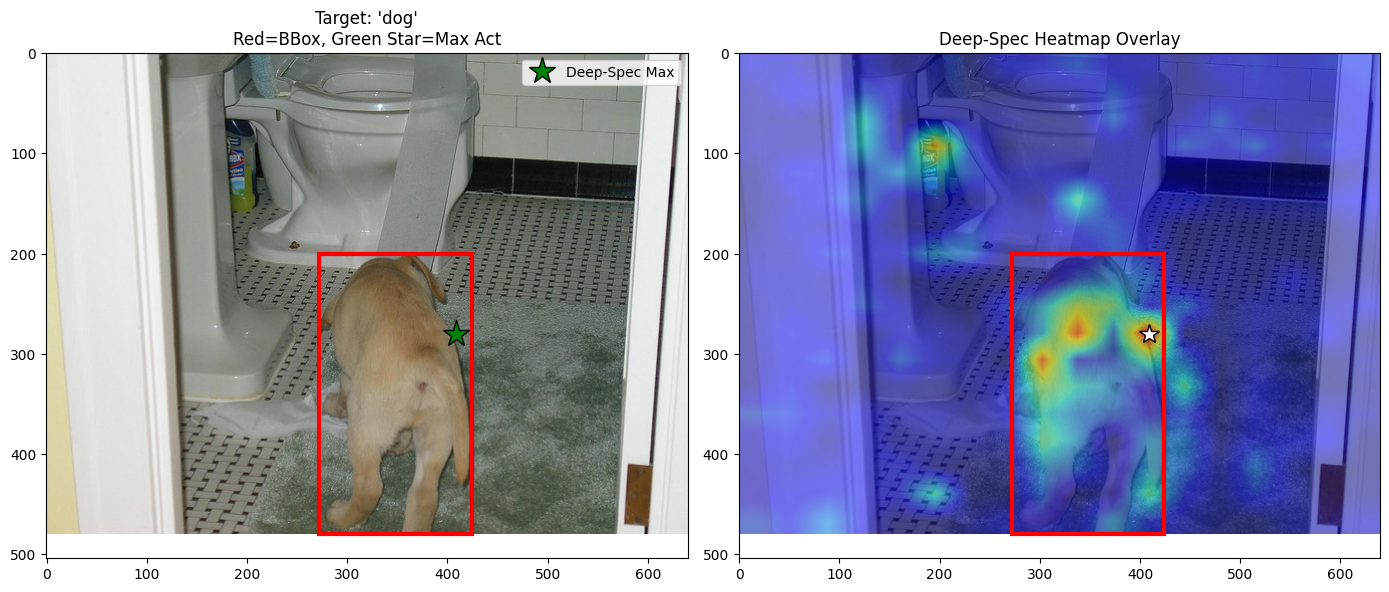

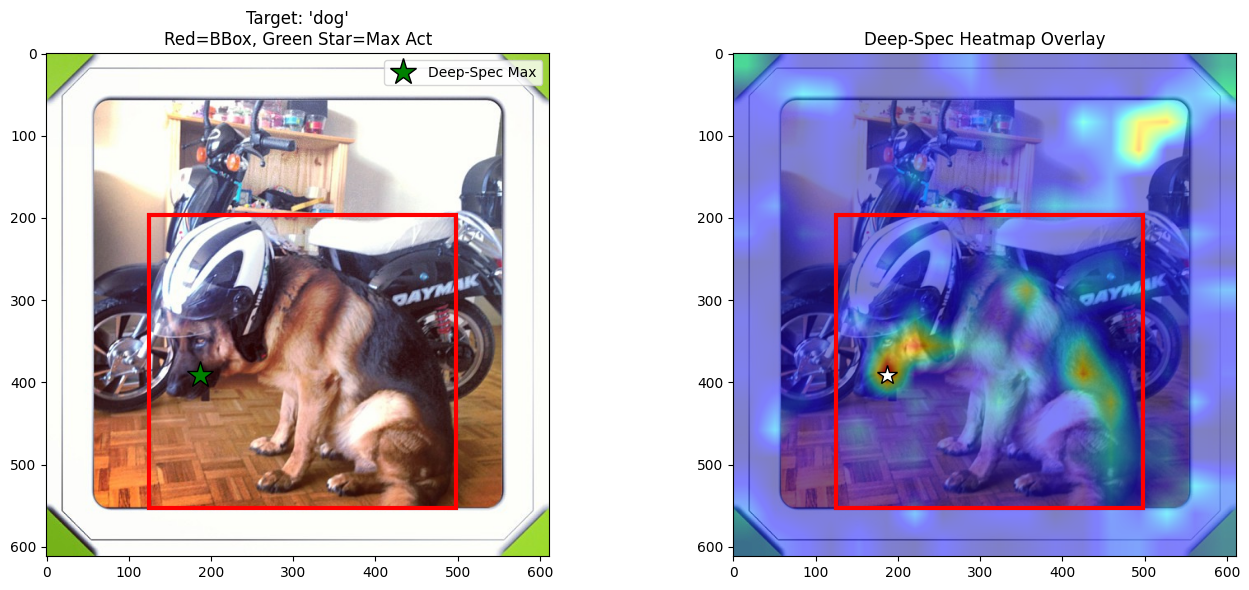

In [ ]:
"""
Deep-Spec Surgical Sanity Check — BridgeTower (Fixed Hooks)
======================================================
Visually verify Bounding Boxes, Heatmaps, and Coordinate Mapping.
Hooks `crossattention.self` directly to guarantee attention capture.
"""

import torch
import numpy as np
from scipy.linalg import eigh
from transformers import AutoModel, AutoTokenizer, BridgeTowerConfig, BridgeTowerImageProcessor
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import json
import os
import requests
from io import BytesIO
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading BridgeTower Foundation Model via Custom Config...")
MODEL_NAME = "BridgeTower/bridgetower-base"

config_url = f"https://huggingface.co/{MODEL_NAME}/raw/main/config.json"
config_dict = requests.get(config_url).json()
config_dict["model_type"] = "bridgetower"
config = BridgeTowerConfig.from_dict(config_dict)

model = AutoModel.from_pretrained(MODEL_NAME, config=config, trust_remote_code=True).to(device)
model.eval()

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({'pad_token': '[PAD]'})

image_processor = BridgeTowerImageProcessor.from_pretrained(MODEL_NAME, config=config, trust_remote_code=True)

ANNOTATION_FILE = "instances_val2017.json"
if not os.path.exists(ANNOTATION_FILE):
    print("Downloading MS-COCO validation bounding boxes...")
    import zipfile
    r = requests.get("http://images.cocodataset.org/annotations/annotations_trainval2017.zip", stream=True)
    with open("annotations.zip", 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    with zipfile.ZipFile("annotations.zip", 'r') as zip_ref:
        zip_ref.extract("annotations/instances_val2017.json", ".")

with open(ANNOTATION_FILE, 'r') as f:
    coco_data = json.load(f)

image_urls = {img['id']: img['coco_url'] for img in coco_data['images']}
categories = {cat['id']: cat['name'] for cat in coco_data['categories']}

image_to_objects = {}
for ann in coco_data['annotations']:
    img_id = ann['image_id']
    if img_id not in image_to_objects:
        image_to_objects[img_id] = []
    image_to_objects[img_id].append({
        'category_name': categories[ann['category_id']],
        'bbox': ann['bbox']
    })

print("\nStarting Visual Sanity Check...")
saved_count = 0

for image_id, objects in image_to_objects.items():
    if saved_count >= 3: break

    url = image_urls.get(image_id)
    if not url: continue

    try:
        response = requests.get(url, timeout=10)
        image = Image.open(BytesIO(response.content)).convert("RGB")
    except Exception as e:
        continue

    orig_W, orig_H = image.size

    target_noun = objects[0]['category_name']
    caption = f"a photo of a {target_noun}"

    print(f"\n[{saved_count+1}/3] Image ID: {image_id}")
    print(f"Target Noun: '{target_noun}'")

    pixel_values = image_processor(image, return_tensors="pt")["pixel_values"].to(device)
    text_inputs = tokenizer(caption, return_tensors="pt", padding=True, truncation=True, max_length=128)
    input_ids = text_inputs["input_ids"].to(device)
    attention_mask = text_inputs["attention_mask"].to(device)
    inputs = {"pixel_values": pixel_values, "input_ids": input_ids, "attention_mask": attention_mask}

    patch_size = config.vision_config.patch_size
    ph, pw = pixel_values.shape[-2] // patch_size, pixel_values.shape[-1] // patch_size

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
    special_ids = tokenizer.all_special_ids
    valid_indices = [i for i, idx in enumerate(input_ids[0].tolist()) if idx not in special_ids]

    target_indices = []
    for i, t in enumerate(tokens):
        if i in valid_indices:
            clean_token = t.lower().replace("ġ", "").replace("##", "")
            if any(word in clean_token or clean_token in word for word in target_noun.lower().split()):
                target_indices.append(i)

    if not target_indices:
        print(f"  -> Could not match token for '{target_noun}'. Skipping.")
        continue

    tgt_rel = [valid_indices.index(idx) for idx in target_indices]

    attn_maps = []
    hooks = []
    def hook_fn(module, inp, out):
        if isinstance(out, tuple) and len(out) > 1:
            attn_maps.append(out[1].detach().cpu())
        else:
            print("  -> ERROR: Hook fired but 'out' was not a tuple with attention_probs!")

    for name, module in model.named_modules():
        if "cross_modal_text_layers" in name and name.endswith("crossattention.self"):
            hooks.append(module.register_forward_hook(hook_fn))

    with torch.no_grad():
        _ = model(**inputs, output_attentions=True)

    for h in hooks: h.remove()

    if not attn_maps:
        print("  -> No attention maps captured. Skipping.")
        continue

    all_layers_attn = torch.stack(attn_maps)
    print(f"  -> Captured {len(attn_maps)} cross-attention layers.")
    print(f"  -> Attention Matrix Shape: {all_layers_attn.shape}")

    # deep-spec
    A_global = all_layers_attn.mean(dim=(0, 1, 2))

    # Text length should be dim 0, Image length should be dim 1.
    # BridgeTower image length is typically (ph*pw + 1) because of the image CLS token.
    # We slice [:, 1:] to drop the Image CLS token.
    if A_global.shape[1] == (ph * pw) + 1:
        A_global = A_global[valid_indices, 1:]
    else:
        A_global = A_global[valid_indices, :]

    A_global = A_global / (A_global.max() + 1e-10)
    W_c = A_global.numpy()

    T_ds, I_ds = W_c.shape
    N = T_ds + I_ds
    W = np.zeros((N, N))
    W[:T_ds, T_ds:] = W_c
    W[T_ds:, :T_ds] = W_c.T

    W = W + 1e-3
    D = np.sum(W, axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(D))
    L_sym = np.eye(N) - D_inv_sqrt @ W @ D_inv_sqrt
    _, eigvecs = eigh(L_sym)

    K_components = min(5, T_ds)
    V_text = eigvecs[:T_ds, 1:K_components+1]
    V_img = eigvecs[T_ds:, 1:K_components+1]
    denoised_affinity = V_text @ V_img.T

    target_affinity = np.abs(denoised_affinity[tgt_rel, :])
    hm_ds = target_affinity.max(axis=0).reshape(ph, pw)
    hm_ds = (hm_ds - hm_ds.min()) / (hm_ds.max() - hm_ds.min() + 1e-10)

    max_idx = np.argmax(hm_ds)
    max_y_patch, max_x_patch = np.unravel_index(max_idx, hm_ds.shape)

    rel_x = (max_x_patch + 0.5) / pw
    rel_y = (max_y_patch + 0.5) / ph
    final_x = rel_x * orig_W
    final_y = rel_y * orig_H

    print(f"  -> Patch Center (Grid {pw}x{ph}): ({max_x_patch}, {max_y_patch})")
    print(f"  -> Projected Image Coordinates: ({final_x:.1f}, {final_y:.1f})")

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].imshow(image)

    all_target_bboxes = [obj['bbox'] for obj in objects if obj['category_name'] == target_noun]
    for bbox in all_target_bboxes:
        x_min, y_min, bbox_w, bbox_h = bbox
        rect = patches.Rectangle((x_min, y_min), bbox_w, bbox_h, linewidth=3, edgecolor='r', facecolor='none')
        axes[0].add_patch(rect)

    axes[0].plot(final_x, final_y, 'g*', markersize=20, markeredgecolor='k', label="Deep-Spec Max")
    axes[0].set_title(f"Target: '{target_noun}'\nRed=BBox, Green Star=Max Act")
    axes[0].legend()

    hm_resized = np.array(Image.fromarray(hm_ds).resize((orig_W, orig_H), Image.BILINEAR))
    axes[1].imshow(image)
    axes[1].imshow(hm_resized, cmap='jet', alpha=0.5)
    for bbox in all_target_bboxes:
        x_min, y_min, bbox_w, bbox_h = bbox
        rect = patches.Rectangle((x_min, y_min), bbox_w, bbox_h, linewidth=3, edgecolor='r', facecolor='none')
        axes[1].add_patch(rect)
    axes[1].plot(final_x, final_y, 'w*', markersize=15, markeredgecolor='k')
    axes[1].set_title("Deep-Spec Heatmap Overlay")

    plt.tight_layout()
    plt.savefig(f"bridgetower_sanity_{saved_count}.png")
    print(f"Saved 'bridgetower_sanity_{saved_count}.png'.")
    saved_count += 1

print("\nAll 3 sanity checks saved. Please examine the images.")

In [ ]:
"""
Deep-Spec Large-Scale Pointing Game Benchmark — BridgeTower (MS-COCO)
==================================================================================
here i Fully integrates the  custom BridgeTower loading,
verified cross-attention matrix extraction, and dynamic gradient hooks.
"""

import torch
import numpy as np
from scipy.linalg import eigh
from transformers import AutoModel, AutoTokenizer, BridgeTowerConfig, BridgeTowerImageProcessor
from datasets import load_dataset
from tqdm import tqdm
import warnings
import logging
import requests
import json
import os
import traceback
from io import BytesIO
from PIL import Image

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
warnings.filterwarnings("ignore")

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading BridgeTower Foundation Model via Custom Config...")
MODEL_NAME = "BridgeTower/bridgetower-base"

config_url = f"https://huggingface.co/{MODEL_NAME}/raw/main/config.json"
config_dict = requests.get(config_url).json()
config_dict["model_type"] = "bridgetower"
config = BridgeTowerConfig.from_dict(config_dict)

model = AutoModel.from_pretrained(MODEL_NAME, config=config, trust_remote_code=True).to(device)
model.eval()

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({'pad_token': '[PAD]'})

image_processor = BridgeTowerImageProcessor.from_pretrained(MODEL_NAME, config=config, trust_remote_code=True)

ANNOTATION_FILE = "instances_val2017.json"
if not os.path.exists(ANNOTATION_FILE):
    print("Downloading MS-COCO validation bounding boxes...")
    import zipfile
    r = requests.get("http://images.cocodataset.org/annotations/annotations_trainval2017.zip", stream=True)
    with open("annotations.zip", 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    with zipfile.ZipFile("annotations.zip", 'r') as zip_ref:
        zip_ref.extract("annotations/instances_val2017.json", ".")
    os.rename("annotations/instances_val2017.json", ANNOTATION_FILE)
    print("Download complete.")

with open(ANNOTATION_FILE, 'r') as f:
    coco_data = json.load(f)

categories = {cat['id']: cat['name'] for cat in coco_data['categories']}
image_to_objects = {}
for ann in coco_data['annotations']:
    img_id = ann['image_id']
    if img_id not in image_to_objects:
        image_to_objects[img_id] = []
    image_to_objects[img_id].append({
        'category_name': categories[ann['category_id']],
        'bbox': ann['bbox']
    })

dataset = load_dataset("phiyodr/coco2017", split="validation", streaming=True)

methods = ["Raw Attention", "Attention Rollout", "ViT-Grad-CAM", "Attn x Grad (Chefer)", "Deep-Spec (Ours)"]
hits = {m: 0 for m in methods}
total_evaluated = 0
NUM_EVALS = 1000

def extract_all_heatmaps(inputs, valid_indices, tgt_rel, ph, pw):
    heatmaps = {}

    attn_maps_no_grad = []
    hooks_ng = []

    def hook_ng(module, inp, out):
        if isinstance(out, tuple) and len(out) > 1:
            attn_maps_no_grad.append(out[1].detach().cpu())

    for name, module in model.named_modules():
        if "cross_modal_text_layers" in name and name.endswith("crossattention.self"):
            hooks_ng.append(module.register_forward_hook(hook_ng))

    with torch.no_grad():
        _ = model(**inputs, output_attentions=True)

    for h in hooks_ng:
        h.remove()

    if not attn_maps_no_grad:
        return None

    all_layers_attn = torch.stack(attn_maps_no_grad)

    # raw attention
    avg_attn = all_layers_attn.mean(dim=(0, 1, 2))
    avg_attn = avg_attn[valid_indices, 1:] # Drop Image CLS token

    hm_raw = avg_attn[tgt_rel].max(dim=0).values.reshape(ph, pw)
    hm_raw = hm_raw / (hm_raw.max() + 1e-10)
    heatmaps["Raw Attention"] = hm_raw.numpy()

    # attention rollout
    T, I = all_layers_attn.shape[-2], all_layers_attn.shape[-1]
    rollout = torch.eye(T + I)

    for layer_attn in all_layers_attn:
        avg_heads = layer_attn.mean(dim=(0, 1))
        full = torch.zeros((T + I, T + I))
        full[:T, T:] = avg_heads
        full[T:, :T] = avg_heads.T
        full = 0.5 * full + 0.5 * torch.eye(T + I)
        rollout = rollout @ full

    text_to_img_rollout = rollout[:T, T:]
    filtered_rollout = text_to_img_rollout[valid_indices, 1:]

    hm_roll = filtered_rollout[tgt_rel].max(dim=0).values.reshape(ph, pw)
    hm_roll = hm_roll / (hm_roll.max() + 1e-10)
    heatmaps["Attention Rollout"] = hm_roll.numpy()

    # ours
    A_global = all_layers_attn.mean(dim=(0, 1, 2))
    A_global = A_global[valid_indices, 1:]
    A_global = A_global / (A_global.max() + 1e-10)
    W_c = A_global.numpy()

    T_ds, I_ds = W_c.shape
    N = T_ds + I_ds
    W = np.zeros((N, N))
    W[:T_ds, T_ds:] = W_c
    W[T_ds:, :T_ds] = W_c.T

    W = W + 1e-3

    D = np.sum(W, axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(D))
    L_sym = np.eye(N) - D_inv_sqrt @ W @ D_inv_sqrt
    _, eigvecs = eigh(L_sym)

    K_components = min(5, T_ds)
    V_text = eigvecs[:T_ds, 1:K_components+1]
    V_img = eigvecs[T_ds:, 1:K_components+1]
    denoised_affinity = V_text @ V_img.T

    target_affinity = np.abs(denoised_affinity[tgt_rel, :])
    hm_ds = target_affinity.max(axis=0).reshape(ph, pw)
    hm_ds = (hm_ds - hm_ds.min()) / (hm_ds.max() - hm_ds.min() + 1e-10)
    heatmaps["Deep-Spec (Ours)"] = hm_ds

    # chefer
    activations, gradients = None, None
    attn_maps_grad, grad_maps = [], []

    def forward_hook_gcam(module, inp, out):
        nonlocal activations
        activations = out[0].detach() if isinstance(out, tuple) else out.detach()

    def backward_hook_gcam(module, grad_in, grad_out):
        nonlocal gradients
        if grad_out and len(grad_out) > 0 and grad_out[0] is not None:
            gradients = grad_out[0].detach()

    def forward_hook_chefer(module, inp, out):
        if isinstance(out, tuple) and len(out) > 1:
            attn = out[1]
            attn_maps_grad.append(attn)
            attn.retain_grad()
            attn.register_hook(lambda g: grad_maps.append(g))

    hooks_grad = []


    target_layer = None
    for module in model.vision_model.modules():
        if isinstance(module, torch.nn.ModuleList) and len(module) >= 6:
            target_layer = module[-1]
            break

    if target_layer is None:
        raise AttributeError("Could not dynamically find the Vision Transformer layers for Grad-CAM.")

    hooks_grad.append(target_layer.register_forward_hook(forward_hook_gcam))
    hooks_grad.append(target_layer.register_full_backward_hook(backward_hook_gcam))

    for name, module in model.named_modules():
        if "cross_modal_text_layers" in name and name.endswith("crossattention.self"):
            hooks_grad.append(module.register_forward_hook(forward_hook_chefer))

    model.zero_grad()
    outputs = model(**inputs, output_attentions=True)

    # USER'S VERIFIED GRADIENT LOGIC
    loss = outputs.pooler_output.mean()
    loss.backward()

    for h in hooks_grad:
        h.remove()

    if gradients is not None and activations is not None:
        weights = gradients.mean(dim=(0, 1))
        cam = (weights * activations).sum(dim=-1).squeeze(0)

        if cam.shape[0] == (ph * pw) + 1:
            cam = cam[1:]

        cam = torch.relu(cam)
        cam = cam.reshape(ph, pw)
        cam = cam / (cam.max() + 1e-10)
        heatmaps["ViT-Grad-CAM"] = cam.detach().cpu().numpy()
    else:
        heatmaps["ViT-Grad-CAM"] = np.zeros((ph, pw))

    # Attn x Grad (Chefer)
    if len(attn_maps_grad) > 0 and len(grad_maps) > 0:
        grad_maps_rev = list(reversed(grad_maps))
        heatmap_chefer = torch.zeros_like(attn_maps_grad[0].mean(dim=(0, 1)))
        for attn, grad in zip(attn_maps_grad, grad_maps_rev):
            heatmap_chefer += (attn * grad).mean(dim=(0, 1))

        heatmap_chefer = heatmap_chefer / len(attn_maps_grad)
        heatmap_chefer = heatmap_chefer[valid_indices, 1:]
        heatmap_chefer = torch.clamp(heatmap_chefer, min=0)

        hm_chefer = heatmap_chefer[tgt_rel].max(dim=0).values.reshape(ph, pw)
        hm_chefer = hm_chefer / (hm_chefer.max() + 1e-10)
        heatmaps["Attn x Grad (Chefer)"] = hm_chefer.detach().cpu().numpy()
    else:
        heatmaps["Attn x Grad (Chefer)"] = np.zeros((ph, pw))

    return heatmaps


print(f"Starting Golden Run: BridgeTower Pointing Game over {NUM_EVALS} objects...\n")
iterator = iter(dataset)

with tqdm(total=NUM_EVALS, desc="Evaluating", unit="obj") as pbar:
    while total_evaluated < NUM_EVALS:
        try:
            data = next(iterator)
            image_id = data.get('image_id')

            if image_id not in image_to_objects: continue
            objects = image_to_objects[image_id]

            if 'image' in data and data['image'] is not None:
                image = data['image'].convert("RGB")
            elif 'coco_url' in data:
                response = requests.get(data['coco_url'], timeout=10)
                image = Image.open(BytesIO(response.content)).convert("RGB")
            else: continue

            orig_W, orig_H = image.size
            caption = data['captions'][0] if isinstance(data.get('captions'), list) else data.get('text', "")
            if not caption: continue

            target_noun = None
            for obj in objects:
                if obj['category_name'].lower() in caption.lower():
                    target_noun = obj['category_name']
                    break

            if not target_noun: continue
            all_target_bboxes = [obj['bbox'] for obj in objects if obj['category_name'] == target_noun]

            pixel_values = image_processor(image, return_tensors="pt")["pixel_values"].to(device)
            text_inputs = tokenizer(caption, return_tensors="pt", padding=True, truncation=True, max_length=128)
            input_ids = text_inputs["input_ids"].to(device)
            attention_mask = text_inputs["attention_mask"].to(device)

            inputs = {"pixel_values": pixel_values, "input_ids": input_ids, "attention_mask": attention_mask}

            patch_size = config.vision_config.patch_size
            ph, pw = pixel_values.shape[-2] // patch_size, pixel_values.shape[-1] // patch_size

            tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
            special_ids = tokenizer.all_special_ids
            valid_indices = [i for i, idx in enumerate(input_ids[0].tolist()) if idx not in special_ids]

            target_indices = []
            for i, t in enumerate(tokens):
                if i in valid_indices:
                    clean_token = t.lower().replace("ġ", "").replace("##", "")
                    if any(word in clean_token or clean_token in word for word in target_noun.lower().split()):
                        target_indices.append(i)

            if not target_indices: continue

            tgt_rel = [valid_indices.index(idx) for idx in target_indices]

            heatmaps = extract_all_heatmaps(inputs, valid_indices, tgt_rel, ph, pw)
            if heatmaps is None: continue

            for m_name in methods:
                hm = heatmaps[m_name]
                if hm.max() == 0: continue

                max_idx = np.argmax(hm)
                max_y_patch, max_x_patch = np.unravel_index(max_idx, hm.shape)

                rel_x = (max_x_patch + 0.5) / pw
                rel_y = (max_y_patch + 0.5) / ph
                pixel_x = rel_x * orig_W
                pixel_y = rel_y * orig_H

                hit = False
                for bbox in all_target_bboxes:
                    x_min, y_min, bbox_w, bbox_h = bbox
                    x_max, y_max = x_min + bbox_w, y_min + bbox_h
                    if (x_min <= pixel_x <= x_max) and (y_min <= pixel_y <= y_max):
                        hit = True
                        break

                if hit:
                    hits[m_name] += 1

            total_evaluated += 1
            pbar.update(1)

            if total_evaluated % 100 == 0:
                pbar.write(f"\n--- Pointing Game Accuracy ({total_evaluated}/{NUM_EVALS}) ---")
                for m_name in methods:
                    acc = (hits[m_name] / total_evaluated) * 100
                    pbar.write(f"{m_name:<25} | {acc:.1f}%")
                pbar.write("-" * 50)

        except Exception as e:
            print("\n" + "!"*60)
            print("CRASH DETECTED!")
            print("!"*60)
            traceback.print_exc()
            break

print("\n" + "=" * 60)
print(" FINAL POINTING GAME ACCURACY (Zero-Shot Localization) ".center(60))
print("=" * 60)
for m_name in methods:
    acc = (hits[m_name] / max(1, total_evaluated)) * 100
    prefix = ">> " if "Deep-Spec" in m_name else "   "
    print(f"{prefix}{m_name:<22} | {acc:.2f}%")
print("=" * 60)

Loading BridgeTower Foundation Model via Custom Config...


Loading weights:   0%|          | 0/695 [00:00<?, ?it/s]

Starting Golden Run: BridgeTower Pointing Game over 1000 objects...



Evaluating:  10%|█         | 100/1000 [01:34<15:53,  1.06s/obj]


--- Pointing Game Accuracy (100/1000) ---
Raw Attention             | 34.0%
Attention Rollout         | 24.0%
ViT-Grad-CAM              | 18.0%
Attn x Grad (Chefer)      | 54.0%
Deep-Spec (Ours)          | 62.0%
--------------------------------------------------


...


--- Pointing Game Accuracy (800/1000) ---
Raw Attention             | 29.9%
Attention Rollout         | 20.6%
ViT-Grad-CAM              | 15.9%
Attn x Grad (Chefer)      | 50.6%
Deep-Spec (Ours)          | 56.9%
--------------------------------------------------


Evaluating:  90%|█████████ | 900/1000 [14:15<01:03,  1.58obj/s]


--- Pointing Game Accuracy (900/1000) ---
Raw Attention             | 29.8%
Attention Rollout         | 21.0%
ViT-Grad-CAM              | 15.7%
Attn x Grad (Chefer)      | 50.6%
Deep-Spec (Ours)          | 58.3%
--------------------------------------------------


Evaluating: 100%|██████████| 1000/1000 [15:47<00:00,  1.06obj/s]


--- Pointing Game Accuracy (1000/1000) ---
Raw Attention             | 30.1%
Attention Rollout         | 21.4%
ViT-Grad-CAM              | 15.8%
Attn x Grad (Chefer)      | 50.5%
Deep-Spec (Ours)          | 58.3%
--------------------------------------------------

   FINAL POINTING GAME ACCURACY (Zero-Shot Localization)    
   Raw Attention          | 30.10%
   Attention Rollout      | 21.40%
   ViT-Grad-CAM           | 15.80%
   Attn x Grad (Chefer)   | 50.50%
>> Deep-Spec (Ours)       | 58.30%


In [ ]:
!kaggle datasets download -d hsankesara/flickr-image-dataset

Dataset URL: https://www.kaggle.com/datasets/hsankesara/flickr-image-dataset
License(s): CC0-1.0
100% 8.16G/8.16G [06:37<00:00, 22.1MB/s]



In [ ]:
import zipfile
import os

with zipfile.ZipFile('flickr-image-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('flickr30k_images')

print(os.listdir('flickr30k_images'))

['flickr30k_images']


In [ ]:
import os
import xml.etree.ElementTree as ET
from collections import defaultdict
from PIL import Image


IMAGE_DIR = "/content/flickr30k_images/flickr30k_images/flickr30k_images"   # change to the actual folder name (e.g., "flickr-image-dataset" or "flickr30k_images")


REPO_DIR = "flickr30k_entities-master"
if not os.path.exists(REPO_DIR):
    print("Annotation repo not found. Please run the earlier script to download it.")
    exit(1)

ANNO_ZIP = os.path.join(REPO_DIR, "annotations.zip")
if os.path.exists(ANNO_ZIP) and not os.path.exists(os.path.join(REPO_DIR, "Annotations")):
    print("Extracting annotations.zip...")
    import zipfile
    with zipfile.ZipFile(ANNO_ZIP, 'r') as zip_ref:
        zip_ref.extractall(REPO_DIR)


with open(os.path.join(REPO_DIR, "test.txt"), "r") as f:
    test_image_ids = [line.strip().split('.')[0] for line in f]

print(f"Found {len(test_image_ids)} test image IDs in annotation split.")
print(f"   First 5: {test_image_ids[:5]}")


missing = []
existing = []
for img_id in test_image_ids:
    for ext in ['.jpg', '.jpeg', '.png']:
        path = os.path.join(IMAGE_DIR, f"{img_id}{ext}")
        if os.path.exists(path):
            existing.append(img_id)
            break
    else:
        missing.append(img_id)

print(f"\nFound {len(existing)} image files on disk.")
if missing:
    print(f"Missing {len(missing)} images (first 5): {missing[:5]}")
else:
    print("All test images are present!")


if existing:
    sample_ids = existing[:3]
    print("\nAttempting to load sample images...")
    for img_id in sample_ids:
        for ext in ['.jpg', '.jpeg', '.png']:
            path = os.path.join(IMAGE_DIR, f"{img_id}{ext}")
            if os.path.exists(path):
                try:
                    img = Image.open(path).convert("RGB")
                    print(f"  Loaded image {img_id} (size: {img.size})")
                except Exception as e:
                    print(f"  Failed to load {img_id}: {e}")
                break


if existing:
    sample_id = existing[0]
    print(f"\nSample phrases for image {sample_id}:")
    xml_path = os.path.join(REPO_DIR, "Annotations", f"{sample_id}.xml")
    if os.path.exists(xml_path):
        tree = ET.parse(xml_path)
        root = tree.getroot()
        chain_to_phrase = {}
        sent_path = os.path.join(REPO_DIR, "Sentences", f"{sample_id}.txt")
        if os.path.exists(sent_path):
            with open(sent_path, 'r') as f:
                lines = f.readlines()
                for line in lines[1:]:
                    if '#' in line:
                        parts = line.strip().split('#')
                        if len(parts) == 2:
                            chain_id, phrase = parts[0], parts[1]
                            chain_to_phrase[chain_id] = phrase
        phrases = []
        for obj in root.iter('object'):
            chain_id = obj.find('name').text
            phrase = chain_to_phrase.get(chain_id, chain_id)
            phrases.append(phrase)
        for p in phrases[:3]:
            print(f"   - {p}")
    else:
        print("   XML not found for this image.")



In [ ]:
import os
import re
import xml.etree.ElementTree as ET
from PIL import Image


IMAGE_DIR = "/content/flickr30k_images/flickr30k_images/flickr30k_images"
REPO_DIR = "flickr30k_entities-master"


def parse_phrases(sent_path):
    """
    Read the Sentences file and extract a dict mapping chain_id -> phrase.
    The format after the first line is like:
        [/EN#547/people Seven climbers] ... [/EN#548/bodyparts a rock face] ...
    We extract chain_id and the phrase (the text after the slash and before ']').
    """
    chain_to_phrase = {}
    if not os.path.exists(sent_path):
        return chain_to_phrase
    with open(sent_path, 'r') as f:
        lines = f.readlines()
        for line in lines[1:]:
            pattern = r'\[/EN#(\d+)/[^ ]+ (.*?)\]'
            matches = re.findall(pattern, line)
            for chain_id, phrase in matches:
                chain_to_phrase[chain_id] = phrase.strip()
    return chain_to_phrase


sample_id = "1016887272"
sent_path = os.path.join(REPO_DIR, "Sentences", f"{sample_id}.txt")
phrases = parse_phrases(sent_path)
print(f"Parsed phrases for image {sample_id}:")
for cid, ph in list(phrases.items())[:5]:
    print(f"   chain {cid} -> '{ph}'")


xml_path = os.path.join(REPO_DIR, "Annotations", f"{sample_id}.xml")
if os.path.exists(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    print(f"\nObjects from XML (first 5):")
    for i, obj in enumerate(root.iter('object')):
        if i >= 5:
            break
        chain_id = obj.find('name').text
        bbox_elem = obj.find('bndbox')
        if bbox_elem is not None:
            xmin = int(bbox_elem.find('xmin').text)
            ymin = int(bbox_elem.find('ymin').text)
            xmax = int(bbox_elem.find('xmax').text)
            ymax = int(bbox_elem.find('ymax').text)
            phrase = phrases.get(chain_id, chain_id)  # fallback to chain ID if not found
            print(f"   chain {chain_id} -> phrase '{phrase}'  bbox: [{xmin},{ymin},{xmax},{ymax}]")

print("\n" + "=" * 60)
print(" VERIFICATION COMPLETE ".center(60, "="))
print("If you see actual phrases (not just chain IDs), parsing is correct.")
print("=" * 60)

In [ ]:
"""
Deep-Spec Large-Scale Pointing Game Benchmark — BridgeTower (Flickr30k)
========================================================================
Adapted from MS-COCO to Flickr30k Entities. Uses the official annotation
repository and local image directory. Phrase parsing with regex.
"""

import torch
import numpy as np
from scipy.linalg import eigh
from transformers import AutoModel, AutoTokenizer, BridgeTowerConfig, BridgeTowerImageProcessor
from tqdm import tqdm
import warnings
import logging
import os
import zipfile
import xml.etree.ElementTree as ET
from collections import defaultdict
from PIL import Image
import re
import random
import requests
import subprocess

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
warnings.filterwarnings("ignore")

device = "cuda" if torch.cuda.is_available() else "cpu"


IMAGE_DIR = "/content/flickr30k_images/flickr30k_images/flickr30k_images"
REPO_DIR = "flickr30k_entities-master"
NUM_EVALS = 1000
SHUFFLE = True


print("Loading BridgeTower Foundation Model via Custom Config...")
MODEL_NAME = "BridgeTower/bridgetower-base"

config_url = f"https://huggingface.co/{MODEL_NAME}/raw/main/config.json"
config_dict = requests.get(config_url).json()
config_dict["model_type"] = "bridgetower"
config = BridgeTowerConfig.from_dict(config_dict)

model = AutoModel.from_pretrained(MODEL_NAME, config=config, trust_remote_code=True).to(device)
model.eval()

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({'pad_token': '[PAD]'})

image_processor = BridgeTowerImageProcessor.from_pretrained(MODEL_NAME, config=config, trust_remote_code=True)


def parse_phrases(sent_path):
    """Extract chain_id -> phrase mapping from Sentences file."""
    chain_to_phrase = {}
    if not os.path.exists(sent_path):
        return chain_to_phrase
    with open(sent_path, 'r') as f:
        lines = f.readlines()
        for line in lines[1:]:  # skip the full caption (first line)
            pattern = r'\[/EN#(\d+)/[^ ]+ (.*?)\]'
            matches = re.findall(pattern, line)
            for chain_id, phrase in matches:
                chain_to_phrase[chain_id] = phrase.strip()
    return chain_to_phrase


if not os.path.exists(REPO_DIR):
    print("Downloading official annotation repository...")
    subprocess.run(["wget", "-O", "master.zip", "https://github.com/BryanPlummer/flickr30k_entities/archive/refs/heads/master.zip"], check=True)
    subprocess.run(["unzip", "-o", "master.zip"], check=True)
    os.remove("master.zip")

ANNO_ZIP = os.path.join(REPO_DIR, "annotations.zip")
if os.path.exists(ANNO_ZIP) and not os.path.exists(os.path.join(REPO_DIR, "Annotations")):
    print("Extracting annotations.zip...")
    with zipfile.ZipFile(ANNO_ZIP, 'r') as zip_ref:
        zip_ref.extractall(REPO_DIR)

with open(os.path.join(REPO_DIR, "test.txt"), "r") as f:
    test_image_ids = [line.strip().split('.')[0] for line in f]

image_to_objects = defaultdict(list)
for img_id in test_image_ids:
    xml_path = os.path.join(REPO_DIR, "Annotations", f"{img_id}.xml")
    if not os.path.exists(xml_path):
        continue
    try:
        tree = ET.parse(xml_path)
    except:
        continue
    root = tree.getroot()

    sent_path = os.path.join(REPO_DIR, "Sentences", f"{img_id}.txt")
    chain_to_phrase = parse_phrases(sent_path)

    for obj in root.iter('object'):
        chain_id = obj.find('name').text
        bbox_elem = obj.find('bndbox')
        if bbox_elem is None:
            continue
        xmin = int(bbox_elem.find('xmin').text)
        ymin = int(bbox_elem.find('ymin').text)
        xmax = int(bbox_elem.find('xmax').text)
        ymax = int(bbox_elem.find('ymax').text)
        phrase = chain_to_phrase.get(chain_id, chain_id)  # fallback to chain ID if not found
        image_to_objects[img_id].append({
            'category_name': phrase,
            'bbox': [xmin, ymin, xmax - xmin, ymax - ymin]
        })

print(f"Loaded annotations for {len(image_to_objects)} test images.")


methods = ["Raw Attention", "Attention Rollout", "ViT-Grad-CAM", "Attn x Grad (Chefer)", "Deep-Spec (Ours)"]
hits = {m: 0 for m in methods}
total_evaluated = 0


def extract_all_heatmaps(inputs, valid_indices, tgt_rel, ph, pw):
    """
    Extracts heatmaps for all five methods using BridgeTower's cross‑modal attention.
  .
    """
    heatmaps = {}

    attn_maps_no_grad = []
    hooks_ng = []

    def hook_ng(module, inp, out):
        if isinstance(out, tuple) and len(out) > 1:
            attn_maps_no_grad.append(out[1].detach().cpu())

    for name, module in model.named_modules():
        if "cross_modal_text_layers" in name and name.endswith("crossattention.self"):
            hooks_ng.append(module.register_forward_hook(hook_ng))

    with torch.no_grad():
        _ = model(**inputs, output_attentions=True)

    for h in hooks_ng:
        h.remove()

    if not attn_maps_no_grad:
        return None

    all_layers_attn = torch.stack(attn_maps_no_grad)

    # -------------------------------------------------
    # RAW ATTENTION
    # -------------------------------------------------
    avg_attn = all_layers_attn.mean(dim=(0, 1, 2))
    avg_attn = avg_attn[valid_indices, 1:]  # drop image CLS token
    hm_raw = avg_attn[tgt_rel].max(dim=0).values.reshape(ph, pw)
    hm_raw = hm_raw / (hm_raw.max() + 1e-10)
    heatmaps["Raw Attention"] = hm_raw.numpy()

    # -------------------------------------------------
    # ATTENTION ROLLOUT
    # -------------------------------------------------
    T, I = all_layers_attn.shape[-2], all_layers_attn.shape[-1]
    rollout = torch.eye(T + I)

    for layer_attn in all_layers_attn:
        avg_heads = layer_attn.mean(dim=(0, 1))
        full = torch.zeros((T + I, T + I))
        full[:T, T:] = avg_heads
        full[T:, :T] = avg_heads.T
        full = 0.5 * full + 0.5 * torch.eye(T + I)
        rollout = rollout @ full

    text_to_img_rollout = rollout[:T, T:]
    filtered_rollout = text_to_img_rollout[valid_indices, 1:]
    hm_roll = filtered_rollout[tgt_rel].max(dim=0).values.reshape(ph, pw)
    hm_roll = hm_roll / (hm_roll.max() + 1e-10)
    heatmaps["Attention Rollout"] = hm_roll.numpy()

    # our
    A_global = all_layers_attn.mean(dim=(0, 1, 2))
    A_global = A_global[valid_indices, 1:]
    A_global = A_global / (A_global.max() + 1e-10)
    W_c = A_global.numpy()

    T_ds, I_ds = W_c.shape
    N = T_ds + I_ds
    W = np.zeros((N, N))
    W[:T_ds, T_ds:] = W_c
    W[T_ds:, :T_ds] = W_c.T
    W = W + 1e-3

    D = np.sum(W, axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(D))
    L_sym = np.eye(N) - D_inv_sqrt @ W @ D_inv_sqrt
    _, eigvecs = eigh(L_sym)

    K_components = min(5, T_ds)
    V_text = eigvecs[:T_ds, 1:K_components+1]
    V_img = eigvecs[T_ds:, 1:K_components+1]
    denoised_affinity = V_text @ V_img.T

    target_affinity = np.abs(denoised_affinity[tgt_rel, :])
    hm_ds = target_affinity.max(axis=0).reshape(ph, pw)
    hm_ds = (hm_ds - hm_ds.min()) / (hm_ds.max() - hm_ds.min() + 1e-10)
    heatmaps["Deep-Spec (Ours)"] = hm_ds


    activations, gradients = None, None
    attn_maps_grad, grad_maps = [], []

    def forward_hook_gcam(module, inp, out):
        nonlocal activations
        activations = out[0].detach() if isinstance(out, tuple) else out.detach()

    def backward_hook_gcam(module, grad_in, grad_out):
        nonlocal gradients
        if grad_out and len(grad_out) > 0 and grad_out[0] is not None:
            gradients = grad_out[0].detach()

    def forward_hook_chefer(module, inp, out):
        if isinstance(out, tuple) and len(out) > 1:
            attn = out[1]
            attn_maps_grad.append(attn)
            attn.retain_grad()
            attn.register_hook(lambda g: grad_maps.append(g))

    hooks_grad = []

    # Dynamic vision layer for Grad-CAM
    target_layer = None
    for module in model.vision_model.modules():
        if isinstance(module, torch.nn.ModuleList) and len(module) >= 6:
            target_layer = module[-1]
            break
    if target_layer is None:
        raise AttributeError("Could not dynamically find the Vision Transformer layers for Grad-CAM.")

    hooks_grad.append(target_layer.register_forward_hook(forward_hook_gcam))
    hooks_grad.append(target_layer.register_full_backward_hook(backward_hook_gcam))

    for name, module in model.named_modules():
        if "cross_modal_text_layers" in name and name.endswith("crossattention.self"):
            hooks_grad.append(module.register_forward_hook(forward_hook_chefer))

    model.zero_grad()
    outputs = model(**inputs, output_attentions=True)
    loss = outputs.pooler_output.mean()
    loss.backward()

    for h in hooks_grad:
        h.remove()

    # ViT-Grad-CAM
    if gradients is not None and activations is not None:
        weights = gradients.mean(dim=(0, 1))
        cam = (weights * activations).sum(dim=-1).squeeze(0)
        if cam.shape[0] == (ph * pw) + 1:
            cam = cam[1:]
        cam = torch.relu(cam)
        cam = cam.reshape(ph, pw)
        cam = cam / (cam.max() + 1e-10)
        heatmaps["ViT-Grad-CAM"] = cam.detach().cpu().numpy()
    else:
        heatmaps["ViT-Grad-CAM"] = np.zeros((ph, pw))

    # Attn x Grad (Chefer)
    if len(attn_maps_grad) > 0 and len(grad_maps) > 0:
        grad_maps_rev = list(reversed(grad_maps))
        heatmap_chefer = torch.zeros_like(attn_maps_grad[0].mean(dim=(0, 1)))
        for attn, grad in zip(attn_maps_grad, grad_maps_rev):
            heatmap_chefer += (attn * grad).mean(dim=(0, 1))

        heatmap_chefer = heatmap_chefer / len(attn_maps_grad)
        heatmap_chefer = heatmap_chefer[valid_indices, 1:]
        heatmap_chefer = torch.clamp(heatmap_chefer, min=0)

        hm_chefer = heatmap_chefer[tgt_rel].max(dim=0).values.reshape(ph, pw)
        hm_chefer = hm_chefer / (hm_chefer.max() + 1e-10)
        heatmaps["Attn x Grad (Chefer)"] = hm_chefer.detach().cpu().numpy()
    else:
        heatmaps["Attn x Grad (Chefer)"] = np.zeros((ph, pw))

    return heatmaps


print(f"Starting Golden Run: BridgeTower Pointing Game over {NUM_EVALS} Flickr30k entities...\n")

if SHUFFLE:
    random.shuffle(test_image_ids)

evaluated = 0
with tqdm(total=NUM_EVALS, desc="Evaluating", unit="obj") as pbar:
    for img_id in test_image_ids:
        if evaluated >= NUM_EVALS:
            break
        if img_id not in image_to_objects:
            continue
        objects = image_to_objects[img_id]

        img_path = None
        for ext in ['.jpg', '.jpeg', '.png']:
            candidate = os.path.join(IMAGE_DIR, f"{img_id}{ext}")
            if os.path.exists(candidate):
                img_path = candidate
                break
        if img_path is None:
            continue

        try:
            image = Image.open(img_path).convert("RGB")
        except:
            continue
        orig_W, orig_H = image.size

        sent_path = os.path.join(REPO_DIR, "Sentences", f"{img_id}.txt")
        if not os.path.exists(sent_path):
            continue
        with open(sent_path, 'r') as f:
            caption = f.readline().strip()
        if not caption:
            continue

        target_noun = None
        for obj in objects:
            phrase = obj['category_name']
            if phrase.lower() in caption.lower():
                target_noun = phrase
                break
        if not target_noun:
            continue
        all_target_bboxes = [obj['bbox'] for obj in objects if obj['category_name'] == target_noun]

        pixel_values = image_processor(image, return_tensors="pt")["pixel_values"].to(device)
        text_inputs = tokenizer(caption, return_tensors="pt", padding=True, truncation=True, max_length=128)
        input_ids = text_inputs["input_ids"].to(device)
        attention_mask = text_inputs["attention_mask"].to(device)
        inputs = {"pixel_values": pixel_values, "input_ids": input_ids, "attention_mask": attention_mask}

        patch_size = config.vision_config.patch_size
        ph, pw = pixel_values.shape[-2] // patch_size, pixel_values.shape[-1] // patch_size

        tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
        special_ids = tokenizer.all_special_ids
        valid_indices = [i for i, idx in enumerate(input_ids[0].tolist()) if idx not in special_ids]
        target_indices = []
        for i, t in enumerate(tokens):
            if i in valid_indices:
                clean_token = t.lower().replace("ġ", "").replace("##", "")
                if any(word in clean_token or clean_token in word for word in target_noun.lower().split()):
                    target_indices.append(i)
        if not target_indices:
            continue
        tgt_rel = [valid_indices.index(idx) for idx in target_indices]

        heatmaps = extract_all_heatmaps(inputs, valid_indices, tgt_rel, ph, pw)
        if heatmaps is None:
            continue

        for m_name in methods:
            hm = heatmaps[m_name]
            if hm.max() == 0:
                continue
            max_idx = np.argmax(hm)
            max_y_patch, max_x_patch = np.unravel_index(max_idx, hm.shape)
            rel_x = (max_x_patch + 0.5) / pw
            rel_y = (max_y_patch + 0.5) / ph
            pixel_x = rel_x * orig_W
            pixel_y = rel_y * orig_H
            hit = False
            for bbox in all_target_bboxes:
                x_min, y_min, bbox_w, bbox_h = bbox
                x_max, y_max = x_min + bbox_w, y_min + bbox_h
                if (x_min <= pixel_x <= x_max) and (y_min <= pixel_y <= y_max):
                    hit = True
                    break
            if hit:
                hits[m_name] += 1

        evaluated += 1
        pbar.update(1)
        if evaluated % 100 == 0:
            pbar.write(f"\n--- Pointing Game Accuracy ({evaluated}/{NUM_EVALS}) ---")
            for m_name in methods:
                acc = (hits[m_name] / evaluated) * 100
                pbar.write(f"{m_name:<25} | {acc:.1f}%")
            pbar.write("-" * 50)


print("\n" + "=" * 60)
print(" FINAL FLICKR30K POINTING GAME ACCURACY (Phrase Grounding) ".center(60))
print("=" * 60)
for m_name in methods:
    acc = (hits[m_name] / max(1, evaluated)) * 100
    prefix = ">> " if "Deep-Spec" in m_name else "   "
    print(f"{prefix}{m_name:<22} | {acc:.2f}%")
print("=" * 60)

Loading BridgeTower Foundation Model via Custom Config...


config.json:   0%|          | 0.00/1.51k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.31G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/695 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.31G [00:00<?, ?B/s]

...


--- Pointing Game Accuracy (700/1000) ---
Raw Attention             | 20.7%
Attention Rollout         | 17.3%
ViT-Grad-CAM              | 16.4%
Attn x Grad (Chefer)      | 33.1%
Deep-Spec (Ours)          | 44.0%
--------------------------------------------------



Evaluating:  80%|████████  | 800/1000 [05:03<01:05,  3.04obj/s]

Evaluating:  80%|████████  | 800/1000 [05:03<01:05,  3.04obj/s]

Evaluating:  80%|████████  | 800/1000 [05:03<01:05,  3.04obj/s]

Evaluating:  80%|████████  | 800/1000 [05:03<01:05,  3.04obj/s]

Evaluating:  80%|████████  | 800/1000 [05:03<01:05,  3.04obj/s]

Evaluating:  80%|████████  | 800/1000 [05:03<01:05,  3.04obj/s]

Evaluating:  80%|████████  | 800/1000 [05:03<01:05,  3.04obj/s]

Evaluating:  80%|████████  | 800/1000 [05:03<01:05,  3.04obj/s]


--- Pointing Game Accuracy (800/1000) ---
Raw Attention             | 20.6%
Attention Rollout         | 17.2%
ViT-Grad-CAM              | 16.6%
Attn x Grad (Chefer)      | 32.8%
Deep-Spec (Ours)          | 43.2%
--------------------------------------------------



Evaluating:  87%|████████▋ | 872/1000 [05:29<00:48,  2.65obj/s]


 FINAL FLICKR30K POINTING GAME ACCURACY (Phrase Grounding)  
   Raw Attention          | 21.10%
   Attention Rollout      | 17.66%
   ViT-Grad-CAM           | 16.86%
   Attn x Grad (Chefer)   | 33.60%
>> Deep-Spec (Ours)       | 43.35%
